# Import & Setup

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display


plt.style.use('seaborn-v0_8')


# Load raw data


In [2]:
# Danh sách cổ phiếu đã thu thập từ Cafef
symbols = ['FPT', 'HPG', 'VNM', 'REE', 'MWG', 'BID']

data_raw = {}

for symbol in symbols:
    path = f"rawdata/{symbol}_history_2020_2024.csv"
    df_raw = pd.read_csv(path)
    print(f"Đã đọc {symbol}: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")

    # Lưu vào dict để xử lý tiếp
    data_raw[symbol] = df_raw

# Tạo thư mục nếu chưa có
os.makedirs("processed", exist_ok=True)




Đã đọc FPT: 1249 dòng, 11 cột
Đã đọc HPG: 1249 dòng, 11 cột
Đã đọc VNM: 1250 dòng, 11 cột
Đã đọc REE: 1250 dòng, 11 cột
Đã đọc MWG: 1250 dòng, 11 cột
Đã đọc BID: 1250 dòng, 11 cột


In [3]:
for symbol, df in data_raw.items():
    print(f"\n=== {symbol} — RAW DATA ===")
    print(df.shape)
    print(df.head(5))


=== FPT — RAW DATA ===
(1249, 11)
         Ngay  GiaDieuChinh  GiaDongCua        ThayDoi  KhoiLuongKhopLenh  \
0  2020-01-02         21.17        58.6    0.3(0.51 %)             896720   
1  2020-01-03         20.81        57.6    -1(-1.71 %)            2047880   
2  2020-01-06         20.59        57.0  -0.6(-1.04 %)            1091660   
3  2020-01-07         20.99        58.1    1.1(1.93 %)             837240   
4  2020-01-08         20.52        56.8  -1.3(-2.24 %)            1814290   

   GiaTriKhopLenh  KLThoaThuan  GtThoaThuan  GiaMoCua  GiaCaoNhat  GiaThapNhat  
0     52545000000            0            0      58.3        59.0         58.0  
1    118934000000            0            0      58.9        59.1         57.4  
2     62404000000            0            0      57.1        57.6         56.8  
3     48253000000            0            0      57.3        58.1         57.0  
4    103654000000        24230   1504683000      57.5        57.7         56.8  

=== HPG — RAW D

# Clean & Standardize Columns

<h3>Đổi tên các cột cần thiết về chuẩn quốc tế</h3>

In [4]:
def rename_columns(df):
    rename_map = {
        'Ngay': 'Date',
        'GiaMoCua': 'Open',
        'GiaCaoNhat': 'High',
        'GiaThapNhat': 'Low',
        'GiaDongCua': 'Close',
        'KhoiLuongKhopLenh': 'Volume'
}
    df = df.rename(columns= rename_map)
    print("Đã đổi tên cột:")
    display(df.head())
    return df
df_step1 = rename_columns(df_raw)


Đã đổi tên cột:


,Date,GiaDieuChinh,Close,ThayDoi,Volume,GiaTriKhopLenh,KLThoaThuan,GtThoaThuan,Open,High,Low
0,2020-01-02,26.47,46.9,0.75(1.63 %),872620,40798000000,0,0,46.00,47.2,45.9
1,2020-01-03,26.36,46.7,-0.2(-0.43 %),603940,28456000000,0,0,47.35,47.5,46.7
2,2020-01-06,25.85,45.8,-0.9(-1.93 %),794490,36670000000,0,0,46.70,46.7,45.8
3,2020-01-07,26.36,46.7,0.9(1.97 %),526890,24222000000,0,0,45.80,46.7,45.2
4,2020-01-08,26.59,47.1,0.4(0.86 %),1230830,57783000000,0,0,46.00,47.9,45.8


<h3>Xoá các cột không cần thiết</h3>

In [5]:
def drop_unused_columns(df):
    drop_cols = ['GiaDieuChinh', 'ThayDoi', 'GiaTriKhopLenh', 'KLThoaThuan', 'GtThoaThuan']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    print("Đã xoá các cột không cần thiết:")
    display(df.head())
    return df
df_step2 = drop_unused_columns(df_step1)


Đã xoá các cột không cần thiết:


,Date,Close,Volume,Open,High,Low
0,2020-01-02,46.9,872620,46.00,47.2,45.9
1,2020-01-03,46.7,603940,47.35,47.5,46.7
2,2020-01-06,45.8,794490,46.70,46.7,45.8
3,2020-01-07,46.7,526890,45.80,46.7,45.2
4,2020-01-08,47.1,1230830,46.00,47.9,45.8


<h3>Chuẩn hoá kiểu dữ liệu cho cột Ngày</h3>

In [6]:
def clean_dates(df):
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
    df = df.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset=['Date'])
    print("Đã chuẩn hoá cột ngày:")
    display(df.head())
    return df
df_step3 = clean_dates(df_step2)

Đã chuẩn hoá cột ngày:


,Date,Close,Volume,Open,High,Low
0,2020-01-02,46.9,872620,46.00,47.2,45.9
1,2020-01-03,46.7,603940,47.35,47.5,46.7
2,2020-01-06,45.8,794490,46.70,46.7,45.8
3,2020-01-07,46.7,526890,45.80,46.7,45.2
4,2020-01-08,47.1,1230830,46.00,47.9,45.8


<h3>Kết hợp</h3>

In [7]:
def clean_data(df):
    df = rename_columns(df)
    df = drop_unused_columns(df)
    df = clean_dates(df)
    display(df.info())
    return df

cleaned_data = {}

for symbol in symbols:
    raw_path = f"rawdata/{symbol}_history_2020_2024.csv"
    df_raw = pd.read_csv(raw_path)
    print(f"\n{symbol} — Raw data: {df_raw.shape}")
    display(df_raw.head(3))

    df = clean_data(df_raw)
    print(f"{symbol} — After cleaning: {df.shape}")
    display(df.head(5))
    cleaned_data[symbol] = df



FPT — Raw data: (1249, 11)


,Ngay,GiaDieuChinh,GiaDongCua,ThayDoi,KhoiLuongKhopLenh,GiaTriKhopLenh,KLThoaThuan,GtThoaThuan,GiaMoCua,GiaCaoNhat,GiaThapNhat
0,2020-01-02,21.17,58.6,0.3(0.51 %),896720,52545000000,0,0,58.3,59.0,58.0
1,2020-01-03,20.81,57.6,-1(-1.71 %),2047880,118934000000,0,0,58.9,59.1,57.4
2,2020-01-06,20.59,57.0,-0.6(-1.04 %),1091660,62404000000,0,0,57.1,57.6,56.8


Đã đổi tên cột:


,Date,GiaDieuChinh,Close,ThayDoi,Volume,GiaTriKhopLenh,KLThoaThuan,GtThoaThuan,Open,High,Low
0,2020-01-02,21.17,58.6,0.3(0.51 %),896720,52545000000,0,0,58.3,59.0,58.0
1,2020-01-03,20.81,57.6,-1(-1.71 %),2047880,118934000000,0,0,58.9,59.1,57.4
2,2020-01-06,20.59,57.0,-0.6(-1.04 %),1091660,62404000000,0,0,57.1,57.6,56.8
3,2020-01-07,20.99,58.1,1.1(1.93 %),837240,48253000000,0,0,57.3,58.1,57.0
4,2020-01-08,20.52,56.8,-1.3(-2.24 %),1814290,103654000000,24230,1504683000,57.5,57.7,56.8


Đã xoá các cột không cần thiết:


...

,Date,Close,Volume,Open,High,Low
0,2020-01-02,46.9,872620,46.00,47.2,45.9
1,2020-01-03,46.7,603940,47.35,47.5,46.7
2,2020-01-06,45.8,794490,46.70,46.7,45.8
3,2020-01-07,46.7,526890,45.80,46.7,45.2
4,2020-01-08,47.1,1230830,46.00,47.9,45.8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1250 non-null   datetime64[ns]
 1   Close   1250 non-null   float64       
 2   Volume  1250 non-null   int64         
 3   Open    1250 non-null   float64       
 4   High    1250 non-null   float64       
 5   Low     1250 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 58.7 KB


None

BID — After cleaning: (1250, 6)


,Date,Close,Volume,Open,High,Low
0,2020-01-02,46.9,872620,46.00,47.2,45.9
1,2020-01-03,46.7,603940,47.35,47.5,46.7
2,2020-01-06,45.8,794490,46.70,46.7,45.8
3,2020-01-07,46.7,526890,45.80,46.7,45.2
4,2020-01-08,47.1,1230830,46.00,47.9,45.8


In [8]:
for symbol, df in cleaned_data.items():
    print(f"{symbol}: {df['Date'].min()} → {df['Date'].max()}, {df.shape[0]} dòng")

FPT: 2020-01-02 00:00:00 → 2024-12-31 00:00:00, 1249 dòng
HPG: 2020-01-02 00:00:00 → 2024-12-31 00:00:00, 1249 dòng
VNM: 2020-01-02 00:00:00 → 2024-12-31 00:00:00, 1250 dòng
REE: 2020-01-02 00:00:00 → 2024-12-31 00:00:00, 1250 dòng
MWG: 2020-01-02 00:00:00 → 2024-12-31 00:00:00, 1250 dòng
BID: 2020-01-02 00:00:00 → 2024-12-31 00:00:00, 1250 dòng


# Fill missing business days & interpolate

In [9]:
def fill_missing_dates(df):
    if 'Date' not in df.columns:
        print("Cột 'Date' không tồn tại trong dataframe.")
        return None

    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)  # 👈 thêm dayfirst
    df = df.dropna(subset=['Date'])
    if df.empty:
        print("DataFrame rỗng sau khi chuyển Date.")
        return None

    df = df.set_index('Date')
    if df.index.min() is pd.NaT or df.index.max() is pd.NaT:
        print("Ngày bắt đầu hoặc kết thúc bị NaT.")
        return None

    full_range = pd.date_range(df.index.min(), df.index.max(), freq='B')
    df = df.reindex(full_range)
    df.index.name = 'Date'
    df = df.ffill().bfill().reset_index()
    return df

filled_data = {}

for symbol, df in cleaned_data.items():
    print(f"\n{symbol} — Fill missing dates")
    df_filled = fill_missing_dates(df)
    
    if df_filled is None or df_filled.empty:
        print(f"{symbol}: Không tạo được dữ liệu sau fill_missing_dates")
    else:
        print(f"{symbol}: Done — {df_filled.shape}")
        display(df_filled.head(3))
        filled_data[symbol] = df_filled

print(f"\nTổng số mã đã fill thành công: {len(filled_data)}")







FPT — Fill missing dates
FPT: Done — (1304, 6)


,Date,Close,Volume,Open,High,Low
0,2020-01-02,58.6,896720.0,58.3,59.0,58.0
1,2020-01-03,57.6,2047880.0,58.9,59.1,57.4
2,2020-01-06,57.0,1091660.0,57.1,57.6,56.8



HPG — Fill missing dates
HPG: Done — (1304, 6)


,Date,Close,Volume,Open,High,Low
0,2020-01-02,24.00,4232230.0,23.5,24.00,23.35
1,2020-01-03,24.15,7832210.0,24.2,24.35,24.05
2,2020-01-06,24.00,5371060.0,24.0,24.25,23.85



VNM — Fill missing dates
VNM: Done — (1304, 6)


...


MWG — Fill missing dates
MWG: Done — (1304, 6)


,Date,Close,Volume,Open,High,Low
0,2020-01-02,117.0,716290.0,114.0,117.0,113.7
1,2020-01-03,115.3,791020.0,117.0,117.7,115.2
2,2020-01-06,114.7,389250.0,114.8,115.4,114.0



BID — Fill missing dates
BID: Done — (1304, 6)


,Date,Close,Volume,Open,High,Low
0,2020-01-02,46.9,872620.0,46.00,47.2,45.9
1,2020-01-03,46.7,603940.0,47.35,47.5,46.7
2,2020-01-06,45.8,794490.0,46.70,46.7,45.8



Tổng số mã đã fill thành công: 6


# Add Technical Indicators

In [10]:
def add_technical_indicators(df):
    df = df.copy()

    # --- Đường trung bình ---
    df['SMA_10'] = df['Close'].rolling(10).mean()
    df['SMA_50'] = df['Close'].rolling(50).mean()
    df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

    # --- RSI (Relative Strength Index) ---
    delta = df['Close'].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain, index=df.index).rolling(14).mean()
    avg_loss = pd.Series(loss, index=df.index).rolling(14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # --- MACD ---
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26

    return df

# Áp dụng cho tất cả mã
indicator_data = {}

for symbol, df in filled_data.items():
    print(f"\n{symbol} — Adding indicators")

    df_ind = add_technical_indicators(df)
    df_ind = df_ind.reset_index()  # đảm bảo có cột 'Date'

    display(df_ind[['Date','Close','SMA_10','EMA_10','RSI','MACD']].head(10))
    indicator_data[symbol] = df_ind




FPT — Adding indicators


,Date,Close,SMA_10,EMA_10,RSI,MACD
0,2020-01-02,58.6,NaN,58.600000,NaN,0.000000
1,2020-01-03,57.6,NaN,58.418182,NaN,-0.079772
2,2020-01-06,57.0,NaN,58.160331,NaN,-0.189226
3,2020-01-07,58.1,NaN,58.149361,NaN,-0.185074
4,2020-01-08,56.8,NaN,57.904023,NaN,-0.283416
5,2020-01-09,57.6,NaN,57.848746,NaN,-0.293418
6,2020-01-10,57.5,NaN,57.785338,NaN,-0.305887
7,2020-01-13,57.1,NaN,57.660731,NaN,-0.344079
8,2020-01-14,57.0,NaN,57.540598,NaN,-0.378057
9,2020-01-15,57.0,57.43,57.442307,NaN,-0.400371



HPG — Adding indicators


,Date,Close,SMA_10,EMA_10,RSI,MACD
0,2020-01-02,24.00,NaN,24.000000,NaN,0.000000
1,2020-01-03,24.15,NaN,24.027273,NaN,0.011966
2,2020-01-06,24.00,NaN,24.022314,NaN,0.009239
3,2020-01-07,23.70,NaN,23.963711,NaN,-0.016935
4,2020-01-08,23.45,NaN,23.870309,NaN,-0.057192
5,2020-01-09,24.00,NaN,23.893890,NaN,-0.044205
6,2020-01-10,24.20,NaN,23.949546,NaN,-0.017572
7,2020-01-13,24.25,NaN,24.004174,NaN,0.007483
8,2020-01-14,25.00,NaN,24.185233,NaN,0.086856
9,2020-01-15,25.15,24.19,24.360645,NaN,0.160020



VNM — Adding indicators


...

,Date,Close,SMA_10,EMA_10,RSI,MACD
0,2020-01-02,36.95,NaN,36.950000,NaN,0.000000
1,2020-01-03,36.50,NaN,36.868182,NaN,-0.035897
2,2020-01-06,36.45,NaN,36.792149,NaN,-0.067602
3,2020-01-07,36.65,NaN,36.766304,NaN,-0.075716
4,2020-01-08,35.70,NaN,36.572430,NaN,-0.156995
5,2020-01-09,35.70,NaN,36.413806,NaN,-0.218885
6,2020-01-10,35.70,NaN,36.284023,NaN,-0.264881
7,2020-01-13,35.75,NaN,36.186928,NaN,-0.293910
8,2020-01-14,35.80,NaN,36.116578,NaN,-0.309315
9,2020-01-15,35.55,36.075,36.013564,NaN,-0.337803



MWG — Adding indicators


,Date,Close,SMA_10,EMA_10,RSI,MACD
0,2020-01-02,117.0,NaN,117.000000,NaN,0.000000
1,2020-01-03,115.3,NaN,116.690909,NaN,-0.135613
2,2020-01-06,114.7,NaN,116.328926,NaN,-0.288179
3,2020-01-07,115.6,NaN,116.196394,NaN,-0.332633
4,2020-01-08,112.8,NaN,115.578868,NaN,-0.587032
5,2020-01-09,114.5,NaN,115.382710,NaN,-0.644046
6,2020-01-10,115.1,NaN,115.331308,NaN,-0.633512
7,2020-01-13,114.5,NaN,115.180161,NaN,-0.665902
8,2020-01-14,113.9,NaN,114.947405,NaN,-0.731554
9,2020-01-15,114.0,114.74,114.775149,NaN,-0.766676



BID — Adding indicators


,Date,Close,SMA_10,EMA_10,RSI,MACD
0,2020-01-02,46.90,NaN,46.900000,NaN,0.000000
1,2020-01-03,46.70,NaN,46.863636,NaN,-0.015954
2,2020-01-06,45.80,NaN,46.670248,NaN,-0.100067
3,2020-01-07,46.70,NaN,46.675657,NaN,-0.093033
4,2020-01-08,47.10,NaN,46.752811,NaN,-0.054552
5,2020-01-09,49.65,NaN,47.279572,NaN,0.179637
6,2020-01-10,51.30,NaN,48.010559,NaN,0.492695
7,2020-01-13,50.10,NaN,48.390457,NaN,0.636628
8,2020-01-14,50.10,NaN,48.701283,NaN,0.742140
9,2020-01-15,51.00,48.535,49.119232,NaN,0.888144


# Xử lý NaN sau rolling

In [11]:
cleaned_final = {}

for symbol, df in indicator_data.items():
    n_before = df.isna().sum().sum()
    df = df.dropna().reset_index(drop=True)
    n_after = df.isna().sum().sum()
    print(f"\n{symbol} — Dropped NaN: {n_before} → {n_after}, Final shape: {df.shape}")
    cleaned_final[symbol] = df



FPT — Dropped NaN: 71 → 0, Final shape: (1255, 13)

HPG — Dropped NaN: 71 → 0, Final shape: (1255, 13)

VNM — Dropped NaN: 71 → 0, Final shape: (1255, 13)

REE — Dropped NaN: 71 → 0, Final shape: (1255, 13)

MWG — Dropped NaN: 71 → 0, Final shape: (1255, 13)

BID — Dropped NaN: 71 → 0, Final shape: (1255, 13)


In [12]:
print("cleaned_data:", len(cleaned_data))
for symbol in cleaned_data.keys():
    print(symbol)

cleaned_data: 6
FPT
HPG
VNM
REE
MWG
BID


# Visualize Close Price + Moving Averages

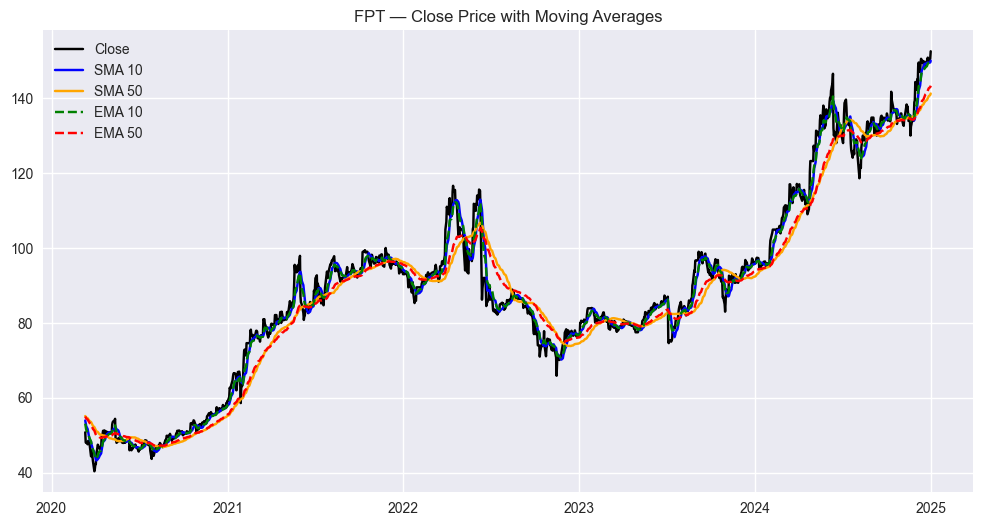

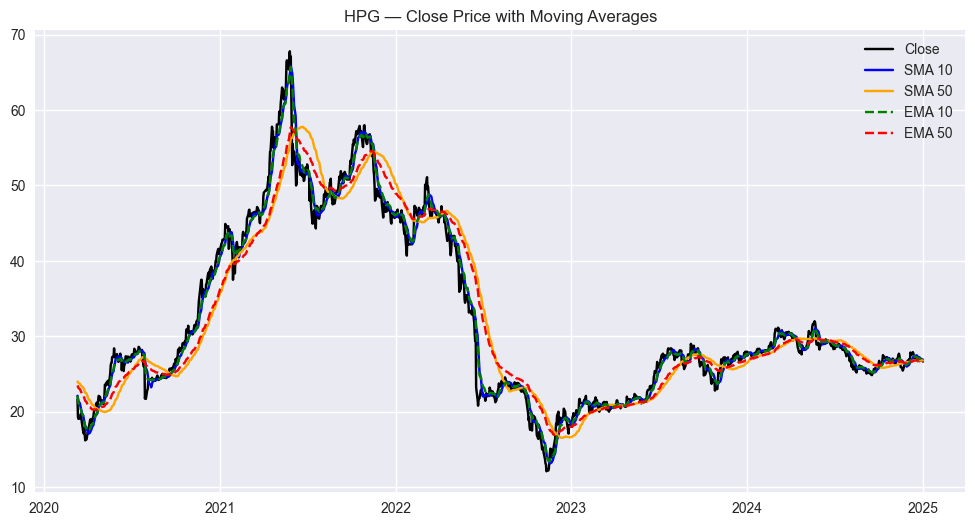

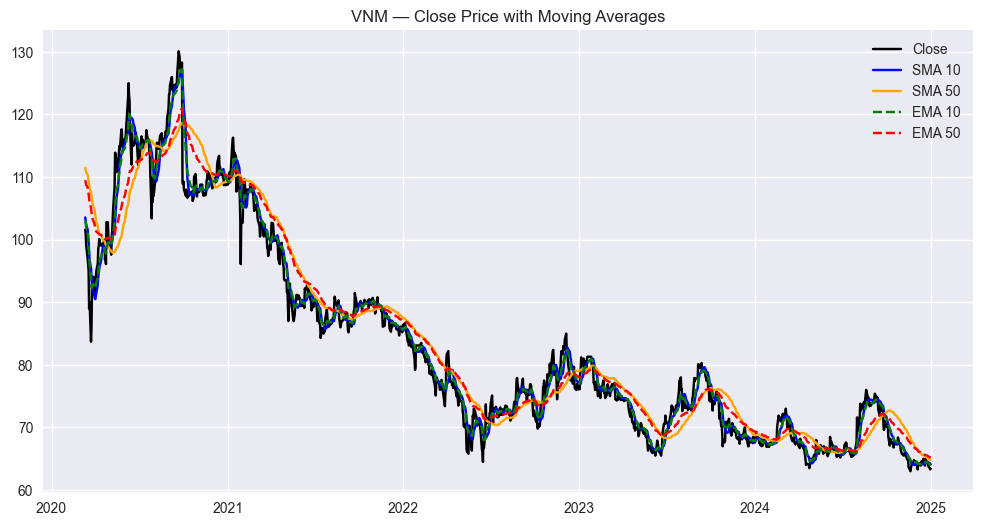

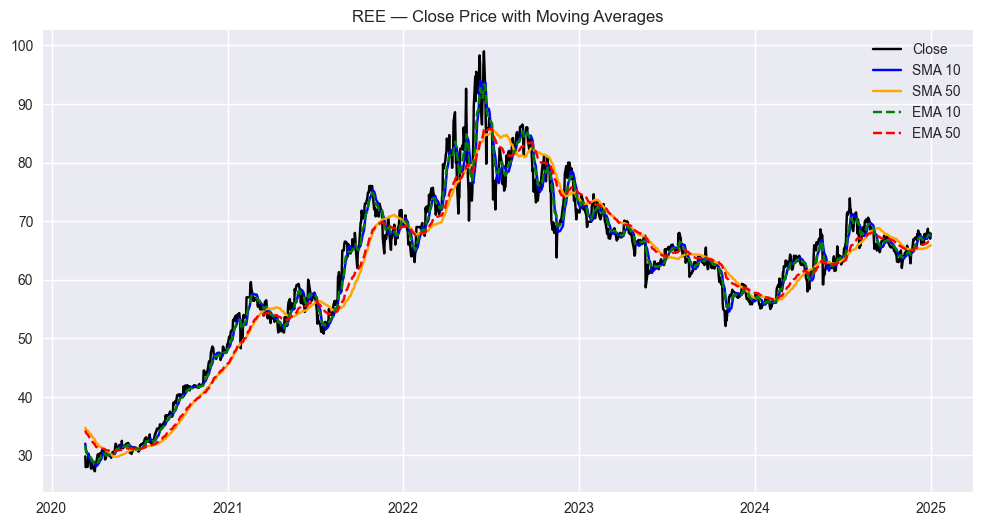

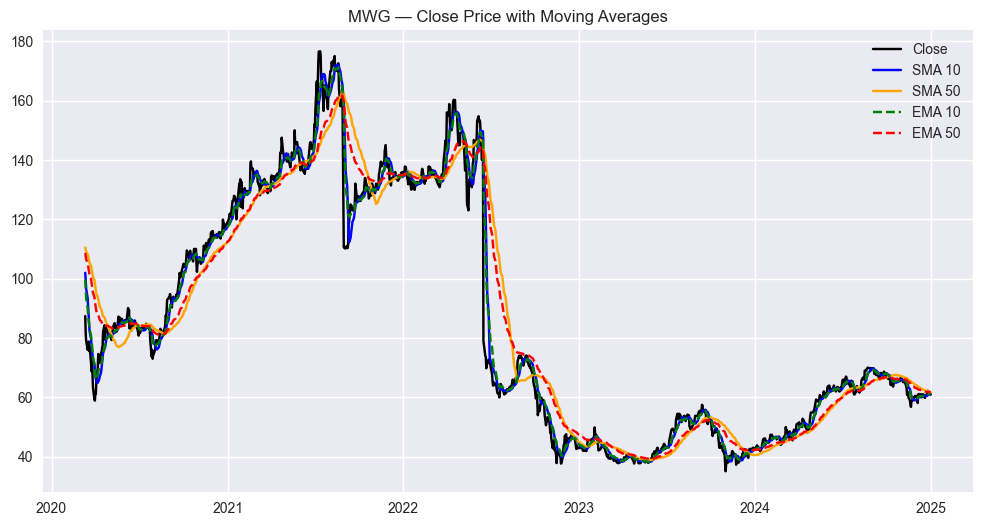

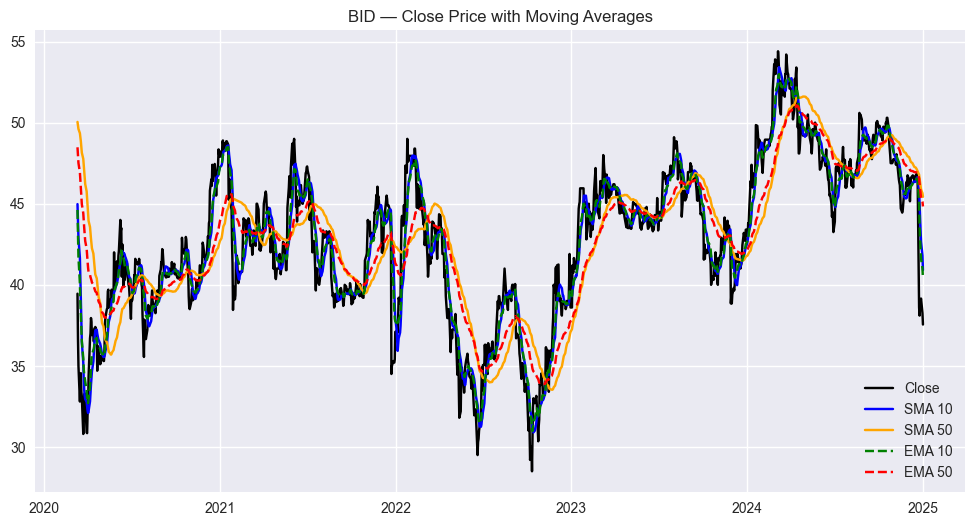

In [13]:
for symbol, df in cleaned_final.items():
    plt.figure(figsize=(12,6))
    plt.plot(df['Date'], df['Close'], label='Close', color='black')
    plt.plot(df['Date'], df['SMA_10'], label='SMA 10', color='blue')
    plt.plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange')
    plt.plot(df['Date'], df['EMA_10'], '--', label='EMA 10', color='green')
    plt.plot(df['Date'], df['EMA_50'], '--', label='EMA 50', color='red')
    plt.title(f"{symbol} — Close Price with Moving Averages")
    plt.legend()
    plt.grid(True)
    plt.show()  

# Chuẩn bị & lưu scaler trước khi chuẩn hóa

In [14]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib

# Tạo thư mục lưu file
os.makedirs("processed", exist_ok=True)
os.makedirs("scalers", exist_ok=True)

scalers = {}
original_data = {}

for symbol, df in cleaned_final.items():
    print(f"\n=== XỬ LÝ: {symbol} ===")

    # Lưu dữ liệu gốc
    df_raw = df.copy()
    df_raw.to_csv(f"processed/{symbol}_original.csv", index=False)
    original_data[symbol] = df_raw

    # Xác định các cột định lượng để chuẩn hóa
    cols = ['Open', 'High', 'Low', 'Close', 'Volume',
            'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50', 'RSI', 'MACD']

    # Fit scaler theo dữ liệu gốc
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(df_raw[cols])

    # Lưu scaler để dùng lại khi đảo ngược
    joblib.dump(scaler, f"scalers/{symbol}_scaler.pkl")
    scalers[symbol] = scaler

    print(f"{symbol}: Fitted & saved scaler (Min={scaler.data_min_[3]:.2f}, Max={scaler.data_max_[3]:.2f})")



=== XỬ LÝ: FPT ===
FPT: Fitted & saved scaler (Min=40.40, Max=152.50)

=== XỬ LÝ: HPG ===
HPG: Fitted & saved scaler (Min=12.10, Max=67.80)

=== XỬ LÝ: VNM ===
VNM: Fitted & saved scaler (Min=63.00, Max=130.10)

=== XỬ LÝ: REE ===
REE: Fitted & saved scaler (Min=27.30, Max=99.00)

=== XỬ LÝ: MWG ===
MWG: Fitted & saved scaler (Min=35.10, Max=176.60)

=== XỬ LÝ: BID ===
BID: Fitted & saved scaler (Min=28.50, Max=54.40)


# Normalize numerical features

In [15]:
normalized_data = {}

for symbol, df in original_data.items():
    print(f"\n=== CHUẨN HÓA: {symbol} ===")

    # Load scaler tương ứng
    scaler = joblib.load(f"scalers/{symbol}_scaler.pkl")

    # Các cột cần chuẩn hóa
    cols = ['Open', 'High', 'Low', 'Close', 'Volume',
            'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50', 'RSI', 'MACD']

    # Chuẩn hóa dữ liệu
    df_scaled = df.copy()
    df_scaled[cols] = scaler.transform(df[cols])
    normalized_data[symbol] = df_scaled

    print(f"{symbol}: Normalized data (0–1)")




=== CHUẨN HÓA: FPT ===
FPT: Normalized data (0–1)

=== CHUẨN HÓA: HPG ===
HPG: Normalized data (0–1)

=== CHUẨN HÓA: VNM ===
VNM: Normalized data (0–1)

=== CHUẨN HÓA: REE ===
REE: Normalized data (0–1)

=== CHUẨN HÓA: MWG ===
MWG: Normalized data (0–1)

=== CHUẨN HÓA: BID ===
BID: Normalized data (0–1)


# Split Train & Test Sets


=== CHIA TẬP: FPT ===
FPT: Train=1004 | Test=251


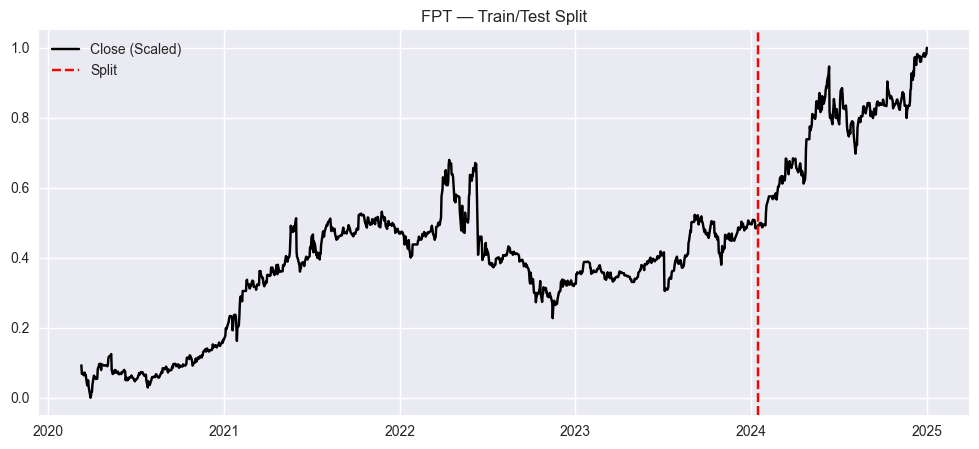


=== CHIA TẬP: HPG ===
HPG: Train=1004 | Test=251


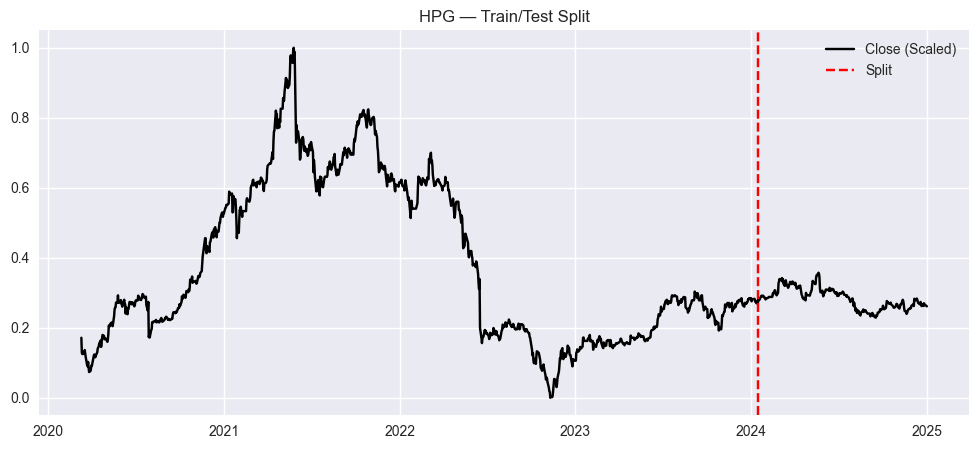


=== CHIA TẬP: VNM ===
VNM: Train=1004 | Test=251


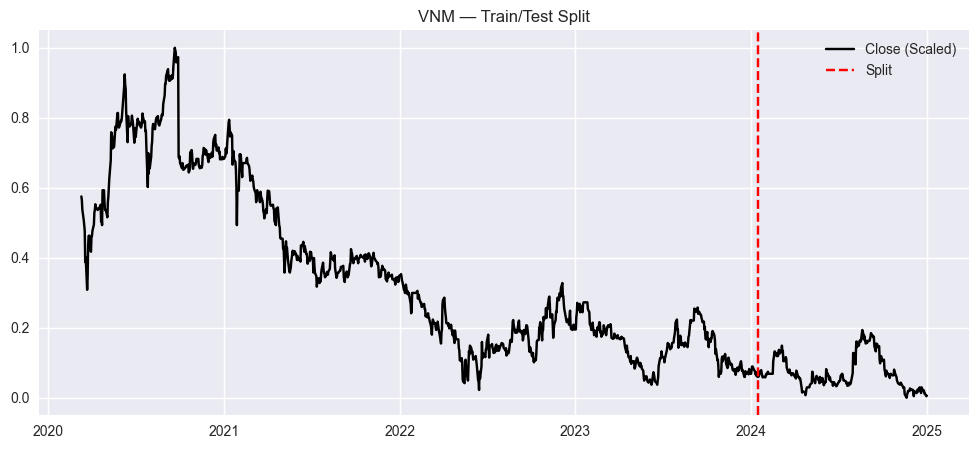


=== CHIA TẬP: REE ===
REE: Train=1004 | Test=251


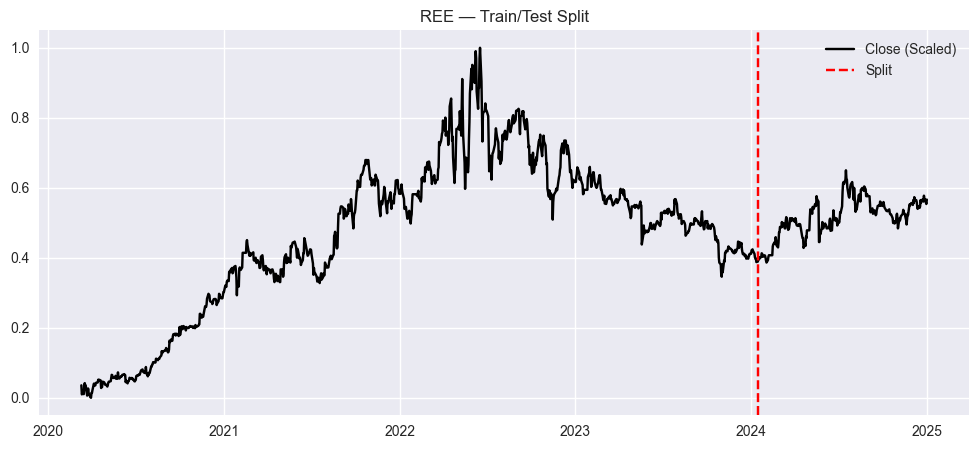


=== CHIA TẬP: MWG ===
MWG: Train=1004 | Test=251


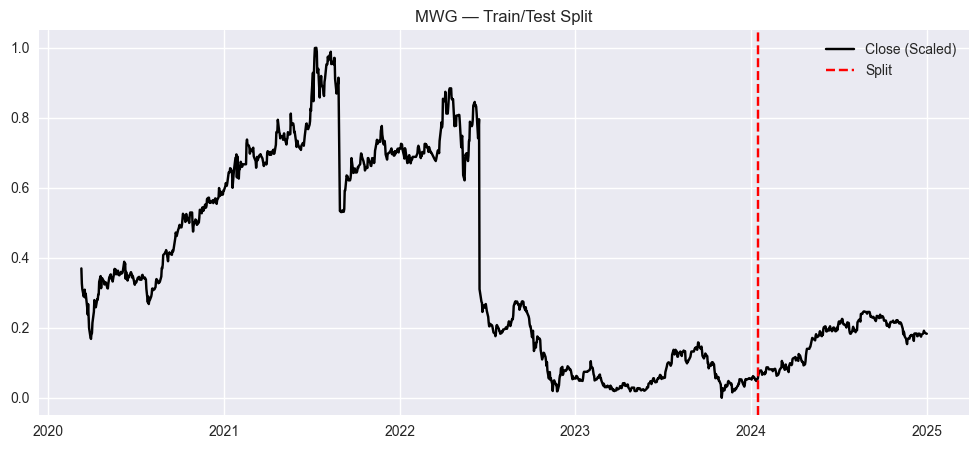


=== CHIA TẬP: BID ===
BID: Train=1004 | Test=251


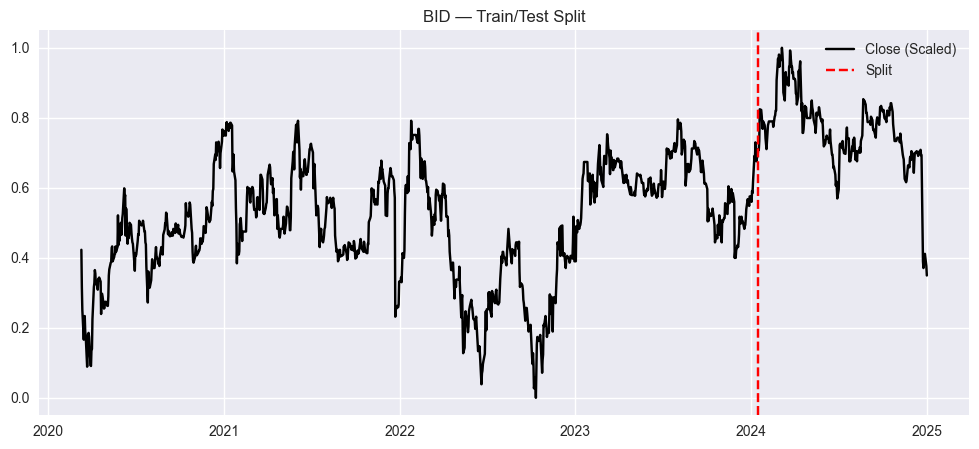

In [16]:
import matplotlib.pyplot as plt

split_data = {}

for symbol, df_scaled in normalized_data.items():
    print(f"\n=== CHIA TẬP: {symbol} ===")

    train_size = int(len(df_scaled) * 0.8)
    train_df = df_scaled.iloc[:train_size]
    test_df = df_scaled.iloc[train_size:]
    split_data[symbol] = (train_df, test_df)

    # Lưu ra CSV
    df_scaled.to_csv(f"processed/{symbol}_processed.csv", index=False)
    train_df.to_csv(f"processed/{symbol}_train.csv", index=False)
    test_df.to_csv(f"processed/{symbol}_test.csv", index=False)

    print(f"{symbol}: Train={len(train_df)} | Test={len(test_df)}")

    # Vẽ kiểm tra điểm chia
    plt.figure(figsize=(12,5))
    plt.plot(df_scaled['Date'], df_scaled['Close'], color='black', label='Close (Scaled)')
    plt.axvline(df_scaled['Date'].iloc[train_size], color='red', linestyle='--', label='Split')
    plt.title(f"{symbol} — Train/Test Split")
    plt.legend()
    plt.grid(True)
    plt.show()



# Building & Training Model

<h3>Import và đọc dữ liệu</h3>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

# Danh sách cổ phiếu
stocks = ['FPT', 'HPG', 'VNM', 'REE', 'MWG', 'BID']

# Chọn các feature cần dùng cho từng cổ phiếu
stock_features = {
    'FPT': ['Open','High','Low','Close','Volume','SMA_10','SMA_50','EMA_10','EMA_50','RSI','MACD'],
    'HPG': ['Open','High','Low','Close','Volume','SMA_10','EMA_10','RSI','MACD','SMA_50','EMA_50'],
    'VNM': ['Open','High','Low','Close','Volume','SMA_10','EMA_10','RSI','MACD','SMA_50','EMA_50'],
    'MWG': ['Open','High','Low','Close','Volume','SMA_10','SMA_50','EMA_10','RSI','MACD','EMA_50'],
    'REE': ['Open','High','Low','Close','Volume','SMA_10','SMA_50','EMA_10','EMA_50','RSI','MACD'],
    'BID': ['Open','High','Low','Close','Volume','SMA_10','EMA_10','SMA_50','EMA_50','RSI','MACD']
}

# Load dữ liệu
data = {}

for stock in stocks:
    df_train = pd.read_csv(f"processed/{stock}_train.csv")
    df_test  = pd.read_csv(f"processed/{stock}_test.csv")
    
    features = stock_features[stock]
    
    data[stock] = {
        'train': df_train[features].values,   # mảng numpy
        'test':  df_test[features].values
    }

<h3>Tạo chuỗi dữ liệu</h3>

In [18]:
# Hàm tạo sequences cho LSTM
def create_sequences(data_array, look_back=90, target_col_index=3):
    X, y = [], []
    for i in range(look_back, len(data_array)):
        X.append(data_array[i-look_back:i, :])  # tất cả features
        y.append(data_array[i, target_col_index])  # Close
    X = np.array(X)
    y = np.array(y)
    return X, y

<h3>Xây dựng và compile model</h3>

In [19]:
# Hàm build LSTM model
def build_lstm_model(input_shape, units_list=[120,120,100], dropout=0.2, learning_rate=0.001):
    model = Sequential()
    # Layer 1
    model.add(LSTM(units_list[0], return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    # Layer 2
    model.add(LSTM(units_list[1], return_sequences=True))
    model.add(Dropout(dropout))
    # Layer 3
    model.add(LSTM(units_list[2], return_sequences=False))
    model.add(Dropout(dropout))
    # Dense
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Hyperparameters riêng từng cổ phiếu
hyperparams = {
    'FPT': {'look_back': 120, 'units1': 150, 'units2': 150, 'units3': 100, 'dropout': 0.3,'lr': 0.0001},
    'HPG': {'look_back': 90, 'units1': 100, 'units2': 100, 'units3': 80,  'dropout': 0.25,'lr': 0.0005},
    'VNM': {'look_back': 90, 'units1': 120, 'units2': 120, 'units3': 100, 'dropout': 0.25,'lr': 0.0004},
    'MWG': {'look_back': 100, 'units1': 140, 'units2': 100, 'units3': 80,  'dropout': 0.3,  'lr': 0.0003},
    'REE': {'look_back': 110, 'units1': 150, 'units2': 130, 'units3': 100, 'dropout': 0.25, 'lr': 0.0002},
    'BID': {'look_back': 90,  'units1': 100, 'units2': 80,  'units3': 60,  'dropout': 0.3,  'lr': 0.0005}
}

<h3>Huấn luyện mô hình cho từng cổ phiếu</h3>

In [20]:
from tensorflow.keras.optimizers import Adam
models = {}
histories = {}
predictions_dict = {}

for stock in stocks:
    print(f"\n=== XỬ LÝ CỔ PHIẾU: {stock} ===")
    params = hyperparams[stock]
    look_back = params['look_back']
    
    train_array = data[stock]['train']
    test_array  = data[stock]['test']
    n_features = train_array.shape[1]
    
    # Tạo sequences
    X_train, y_train = create_sequences(train_array, look_back)
    X_test, y_test   = create_sequences(test_array, look_back)
    
    # Build model
    model = build_lstm_model(
        input_shape=(look_back, n_features),
        units_list=[params['units1'], params['units2'], params['units3']],
        dropout=params['dropout'],
        learning_rate=params['lr']
    )
    
    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=120,
        batch_size=16,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )
    
    
    models[stock] = model
    histories[stock] = history


=== XỬ LÝ CỔ PHIẾU: FPT ===


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - loss: 0.0171 - val_loss: 0.0016
Epoch 2/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - loss: 0.0047 - val_loss: 7.6718e-04
Epoch 3/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - loss: 0.0041 - val_loss: 7.2704e-04
Epoch 4/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - loss: 0.0040 - val_loss: 0.0010
Epoch 5/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - loss: 0.0035 - val_loss: 7.9290e-04
Epoch 6/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - loss: 0.0032 - val_loss: 6.8974e-04
Epoch 7/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - loss: 0.0030 - val_loss: 0.0010
Epoch 8/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - loss: 0.0032 - val_loss: 6.8363e-04
Epoch 9/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - loss: 0.0033 - val_loss: 6.9450e-04
Epoch 10/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - loss: 0.0032 - val_loss: 6.8490e-04
Epoch 11/120
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - loss: 0.0031 - val_loss: 8.5680e-0

In [21]:
os.makedirs("models", exist_ok=True)
# --- Lưu model ---
model_path = f"models/{stock}_LSTM_model.keras"
model.save(model_path)
print(f"Đã lưu mô hình {stock} tại: {model_path}")

Đã lưu mô hình BID tại: models/BID_LSTM_model.keras


# LSTM Model

## 1. LOSS graph

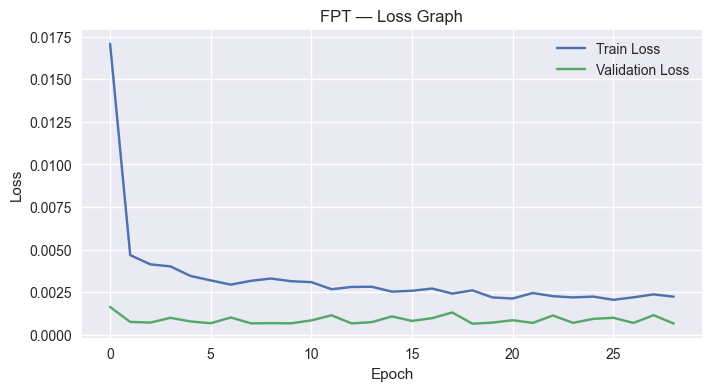

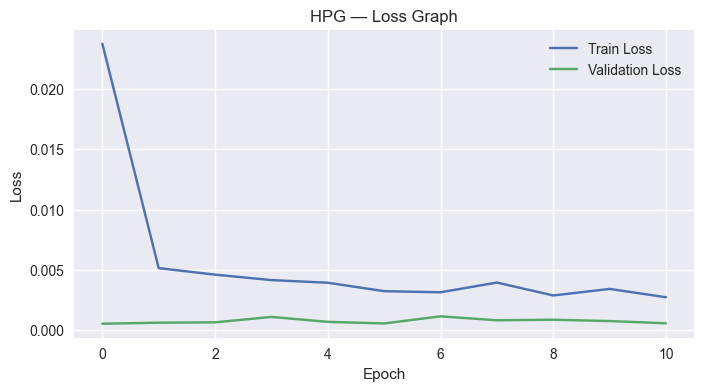

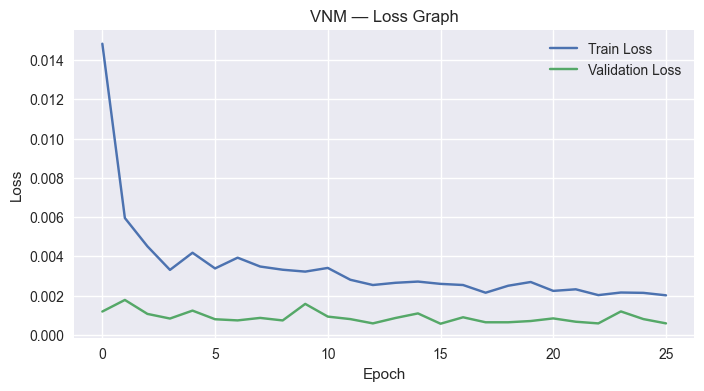

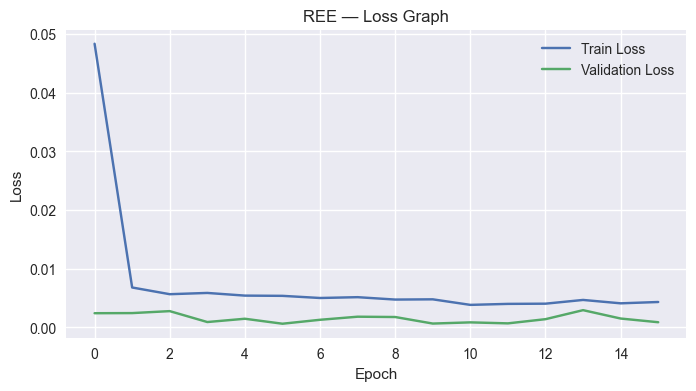

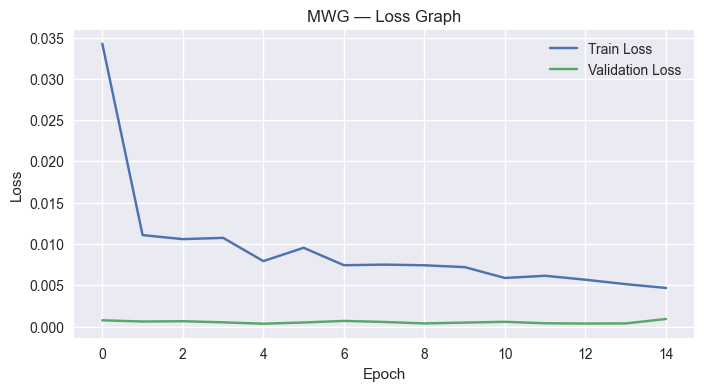

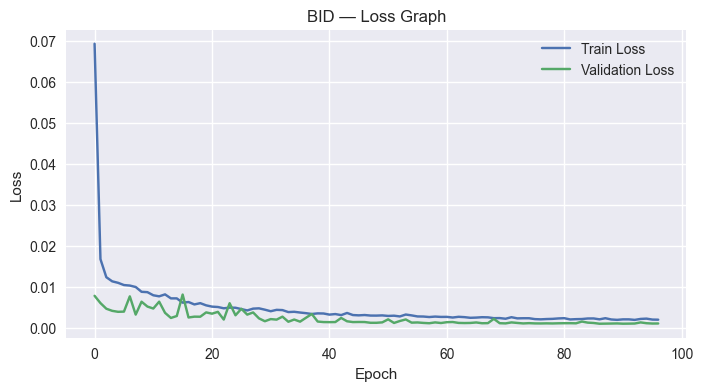

In [22]:
for stock in stocks:
    history = histories[stock]
    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{stock} — Loss Graph")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


## 2. Prediction graph


=== DỰ ĐOÁN CỔ PHIẾU: FPT ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step
10 giá trị đầu tiên:
Thực tế : [128.  131.  135.8 138.7 139.6 137.5 134.  133.  133.8 132.7]
Dự đoán: [122.55 122.24 121.98 121.84 121.88 122.11 122.47 122.83 123.12 123.32]


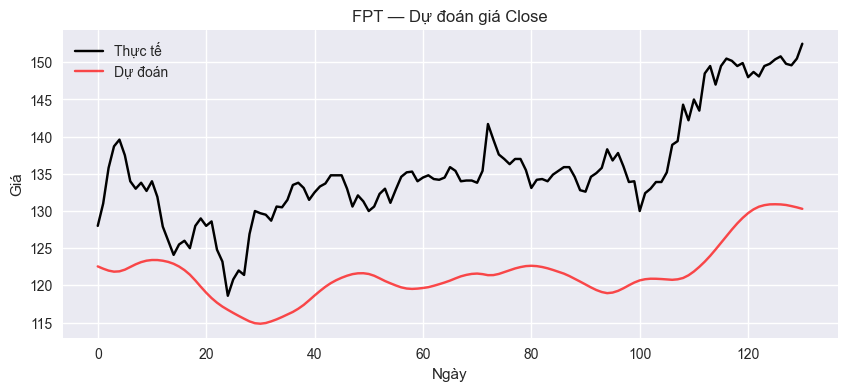


=== DỰ ĐOÁN CỔ PHIẾU: HPG ===
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step
10 giá trị đầu tiên:
Thực tế : [31.85 31.3  29.5  28.9  28.9  29.15 28.6  28.25 28.6  29.  ]
Dự đoán: [30.54 30.81 31.07 31.29 31.45 31.54 31.56 31.51 31.4  31.24]


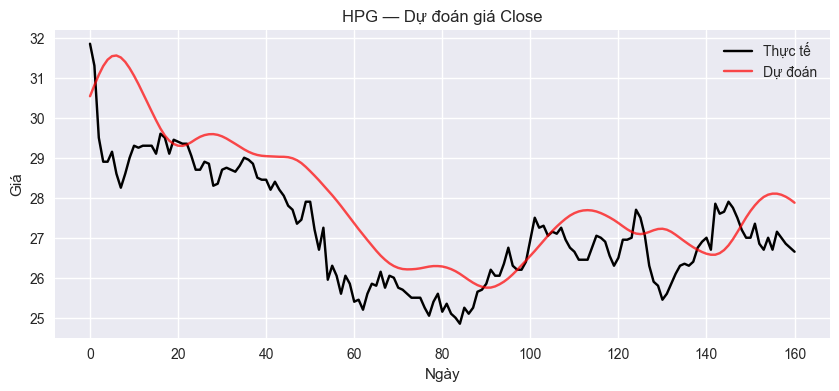


=== DỰ ĐOÁN CỔ PHIẾU: VNM ===
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step
10 giá trị đầu tiên:
Thực tế : [66.2 65.8 67.  66.  66.1 66.8 66.3 65.7 65.4 66.1]
Dự đoán: [68.74 68.71 68.66 68.62 68.59 68.54 68.48 68.49 68.52 68.54]


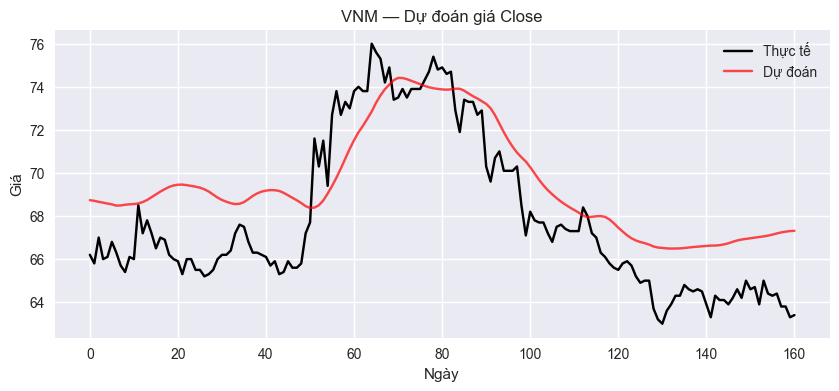


=== DỰ ĐOÁN CỔ PHIẾU: REE ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step
10 giá trị đầu tiên:
Thực tế : [63.5 63.7 65.7 64.5 63.6 64.1 64.  64.  62.6 63.5]
Dự đoán: [61.73 61.83 61.94 62.09 62.29 62.49 62.69 62.89 63.06 63.21]


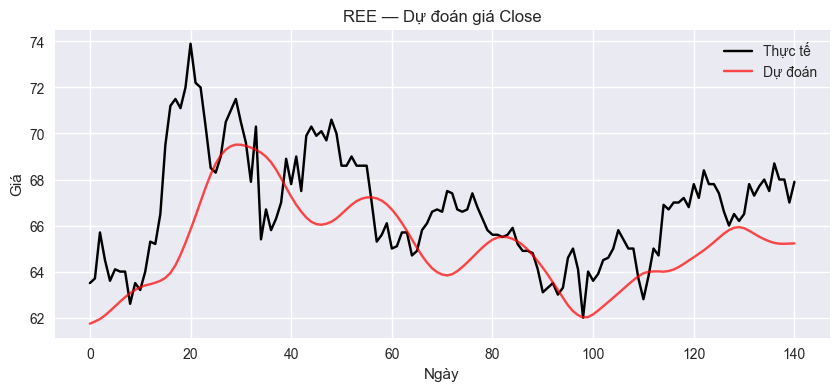


=== DỰ ĐOÁN CỔ PHIẾU: MWG ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step
10 giá trị đầu tiên:
Thực tế : [63.8 62.  61.9 62.1 63.  62.3 63.4 64.  63.  62. ]
Dự đoán: [54.05 54.19 54.31 54.43 54.6  54.83 55.1  55.41 55.76 56.12]


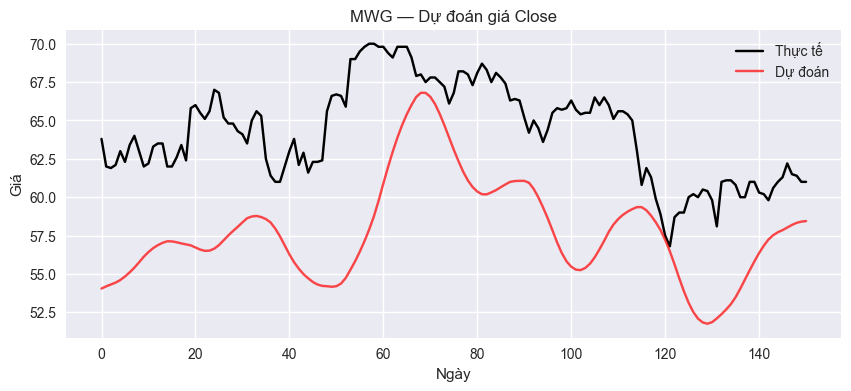


=== DỰ ĐOÁN CỔ PHIẾU: BID ===
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step
10 giá trị đầu tiên:
Thực tế : [50.  49.8 49.5 49.2 48.9 49.1 48.6 47.7 47.1 47.3]
Dự đoán: [48.56 48.87 49.03 48.58 47.93 47.73 48.01 47.88 47.25 46.7 ]


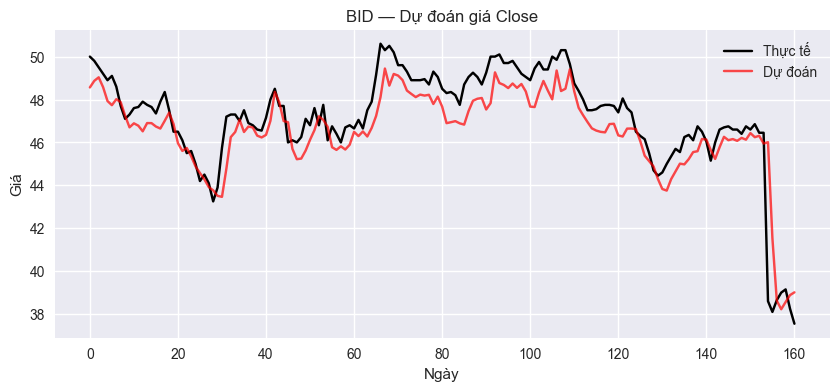

In [23]:
import numpy as np
import matplotlib.pyplot as plt

predictions_dict = {}

for stock in stocks:
    print(f"\n=== DỰ ĐOÁN CỔ PHIẾU: {stock} ===")
    
    # Lấy dữ liệu test và scaler
    test_array = data[stock]['test']
    scaler = scalers[stock]
    
    # Xác định cột Close trong danh sách feature
    features = stock_features[stock]
    target_col_index = features.index('Close')
    n_features = len(features)
    
    # Tạo sequences
    X_test, y_test = create_sequences(test_array, look_back=hyperparams[stock]['look_back'], target_col_index=target_col_index)
    
    # Dự đoán trên scale 0-1
    y_pred_scaled = models[stock].predict(X_test).flatten()
    
    # Tạo dummy array đủ chiều như scaler
    dummy_test = np.zeros((len(y_test), len(scaler.scale_)))
    dummy_test[:, 3] = y_test  # cột Close là cột 3 trong scaler gốc
    y_test_real = scaler.inverse_transform(dummy_test)[:, 3]

    dummy_pred = np.zeros((len(y_pred_scaled), len(scaler.scale_)))
    dummy_pred[:, 3] = y_pred_scaled
    y_pred_real = scaler.inverse_transform(dummy_pred)[:, 3]
    
    # Lưu vào dict
    predictions_dict[stock] = (y_test_real, y_pred_real)

    # In ra 10 giá trị đầu tiên
    print("10 giá trị đầu tiên:")
    print("Thực tế :", np.round(y_test_real[:10], 2))
    print("Dự đoán:", np.round(y_pred_real[:10], 2))
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10,4))
    plt.plot(y_test_real, label='Thực tế', color='black')
    plt.plot(y_pred_real, label='Dự đoán', color='red', alpha=0.7)
    plt.title(f"{stock} — Dự đoán giá Close")
    plt.xlabel('Ngày')
    plt.ylabel('Giá')
    plt.legend()
    plt.show()


# MSE

In [24]:
for stock, (y_real, y_pred) in predictions_dict.items():
    mse = mean_squared_error(y_real, y_pred)
    print(f"{stock} — MSE: {mse:.2f}")



FPT — MSE: 219.58
HPG — MSE: 1.18
VNM — MSE: 5.43
REE — MSE: 6.31
MWG — MSE: 51.34
BID — MSE: 1.35


# RMSE & NRMSE


In [25]:
for stock, (y_real, y_pred) in predictions_dict.items():
    # Ép về float 1D
    y_real = np.array(y_real).flatten().astype(float)
    y_pred = np.array(y_pred).flatten().astype(float)
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    
    # NRMSE chuẩn, luôn dương
    nrmse = rmse / np.mean(np.abs(y_real)) * 100  # %
    
    print(f"{stock} — RMSE: {rmse:.2f}, NRMSE: {nrmse:.2f}%")


FPT — RMSE: 14.82, NRMSE: 10.94%
HPG — RMSE: 1.09, NRMSE: 4.00%
VNM — RMSE: 2.33, NRMSE: 3.43%
REE — RMSE: 2.51, NRMSE: 3.76%
MWG — RMSE: 7.16, NRMSE: 11.15%
BID — RMSE: 1.16, NRMSE: 2.46%
